# Word-level bounding boxes with docling

Parse a PDF with [docling](https://github.com/docling-project/docling) and draw a box around **every word**.

Two paths are covered:

1. **Digital PDF** &rarr; docling returns real `word_cells` from the PDF text layer (exact boxes).
2. **Scanned PDF** &rarr; OCR returns *lines*, so words are cut out of the line box proportionally
   to their character offsets (`estimated=True`).

Green = native text-layer word, red = OCR word.

Run with `uv run jupyter lab notebooks/word_bboxes.ipynb`.

In [1]:
from pathlib import Path

from IPython.display import display

from docling_parser import draw_word_boxes, parse_pdf

DATA = Path.cwd().parent / "data" if Path.cwd().name == "notebooks" else Path("data")
SAMPLE = DATA / "sample.pdf"
SCAN = DATA / "scanned.pdf"
print(SAMPLE, SAMPLE.exists())

/Users/ngam/dev/docling-parser/data/sample.pdf True


## 1. Digital PDF &mdash; native word boxes

In [2]:
parsed = parse_pdf(SAMPLE, ocr=True, page_range=(1, 1), image_scale=2.0)

page = parsed.pages[0]
print(f"page {page.page_no}: {page.width:.0f}x{page.height:.0f} pt, {len(page.words)} words")
print(f"image {page.image.size} px, scale {page.image_scale:.1f} px/pt")

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

page 1: 612x792 pt, 315 words
image (1224, 1584) px, scale 2.0 px/pt


In [3]:
for word in page.words[:12]:
    print(
        f"{word.text:<14} "
        f"l={word.left:7.1f} t={word.top:7.1f} r={word.right:7.1f} b={word.bottom:7.1f}  "
        f"conf={word.confidence:.2f} ocr={word.from_ocr} est={word.estimated}"
    )

Docling        l=  212.6 t=  225.4 r=  269.0 b=  240.8  conf=1.00 ocr=False est=False
Technical      l=  273.3 t=  225.4 r=  343.5 b=  240.8  conf=1.00 ocr=False est=False
Report         l=  347.8 t=  225.4 r=  399.4 b=  240.8  conf=1.00 ocr=False est=False
Version        l=  283.3 t=  280.0 r=  313.7 b=  288.6  conf=1.00 ocr=False est=False
1.0            l=  316.2 t=  280.0 r=  328.7 b=  288.6  conf=1.00 ocr=False est=False
Christoph      l=  118.1 t=  310.5 r=  161.3 b=  319.4  conf=1.00 ocr=False est=False
Auer           l=  163.8 t=  310.5 r=  184.8 b=  319.4  conf=1.00 ocr=False est=False
Maksym         l=  194.8 t=  310.5 r=  231.9 b=  319.4  conf=1.00 ocr=False est=False
Lysak          l=  234.4 t=  310.5 r=  259.8 b=  319.4  conf=1.00 ocr=False est=False
Ahmed          l=  269.8 t=  310.5 r=  300.8 b=  319.4  conf=1.00 ocr=False est=False
Nassar         l=  303.3 t=  310.5 r=  332.6 b=  319.4  conf=1.00 ocr=False est=False
Michele        l=  342.6 t=  310.5 r=  376.3 b=  319.4

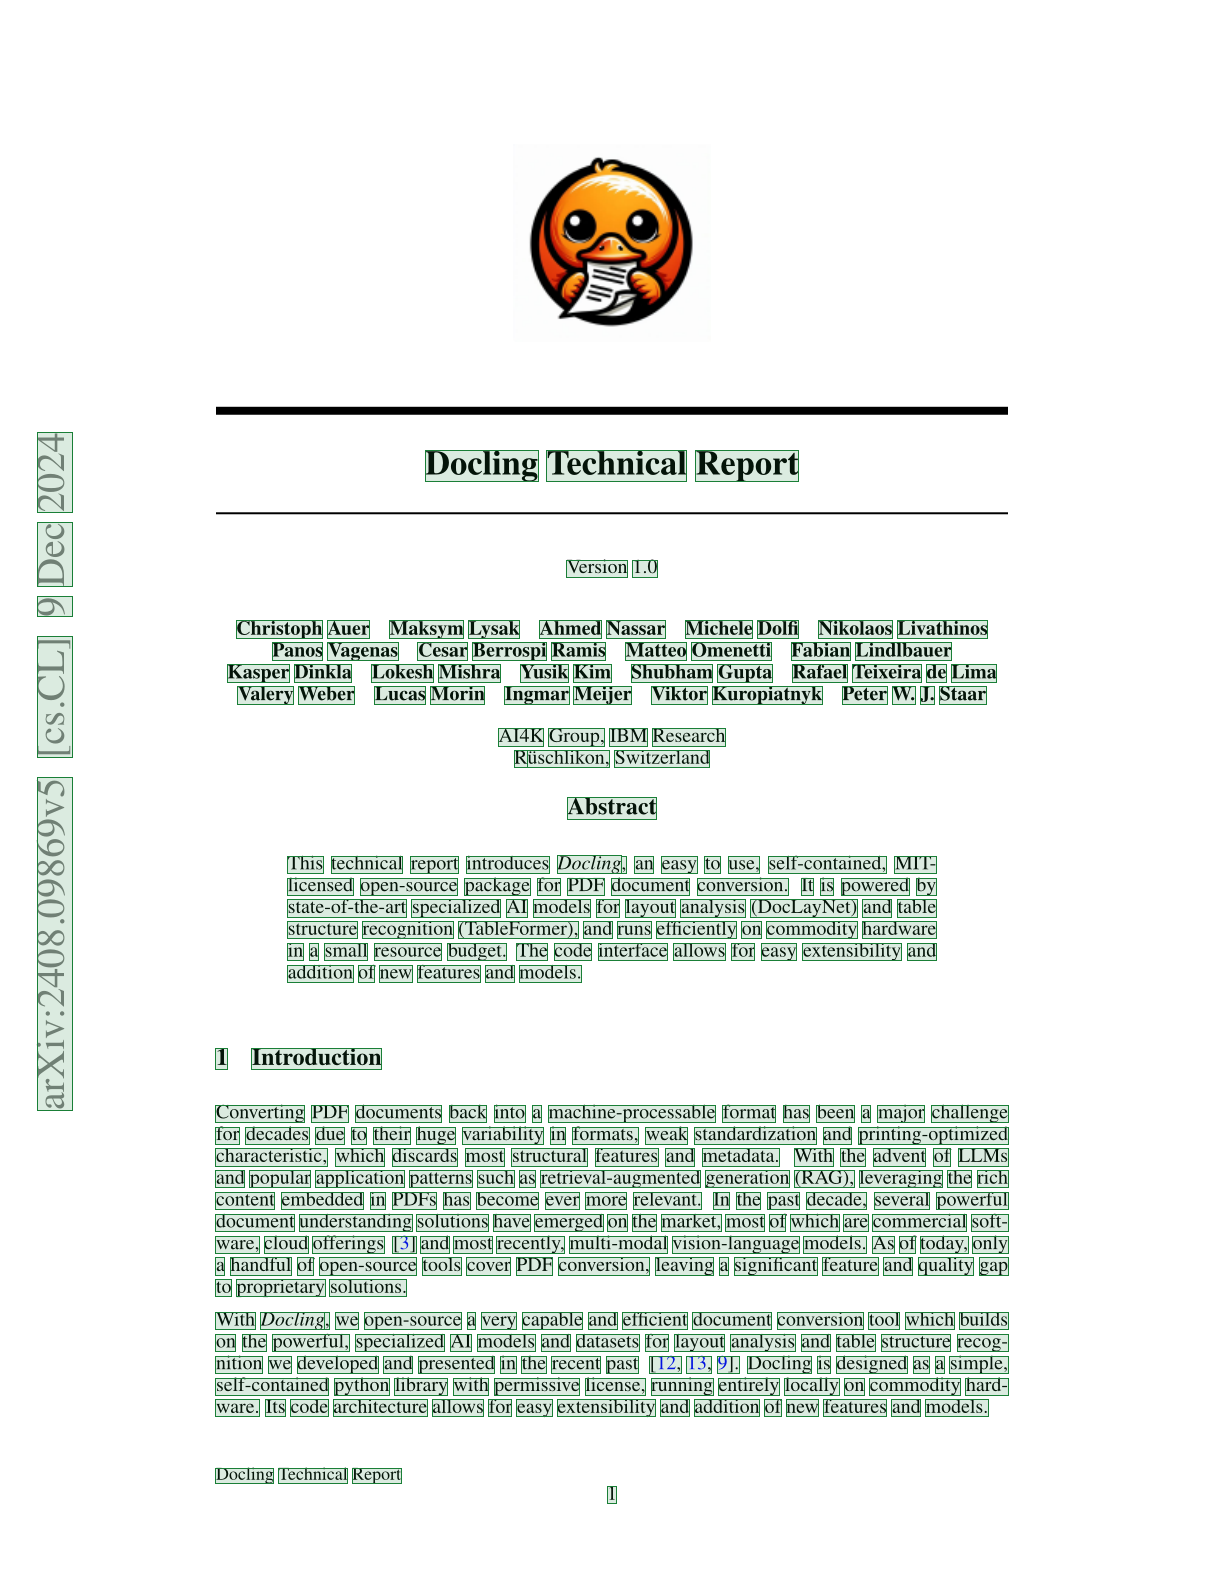

In [4]:
overlay = draw_word_boxes(page)
display(overlay)

### Zoom in, with the recognized text printed above each box

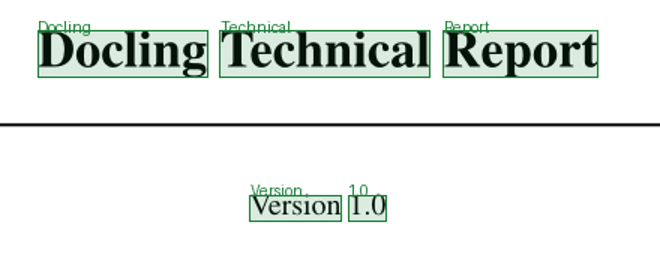

In [5]:
def zoom(page, box_pt, show_text=True, factor=3):
    """Crop a (left, top, right, bottom) region given in PDF points."""
    img = draw_word_boxes(page, show_text=show_text)
    s = page.image_scale
    crop = img.crop(tuple(int(v * s) for v in box_pt))
    return crop.resize((crop.width * factor // 2, crop.height * factor // 2))


display(zoom(page, (200, 215, 420, 300)))

## 2. Scanned PDF &mdash; OCR word boxes

The demo scan is built from the rendered first page (an image-only PDF, no text layer)
so the notebook is self-contained.

In [6]:
if not SCAN.exists():
    rendered = parse_pdf(SAMPLE, ocr=False, page_range=(1, 1), image_scale=3.0)
    rendered.pages[0].image.convert("RGB").save(SCAN, resolution=216.0, quality=95)
    print("created", SCAN)

scanned = parse_pdf(SCAN, ocr=True, force_full_page_ocr=True, image_scale=2.0)
scan_page = scanned.pages[0]
print(f"{len(scan_page.words)} OCR words")
print(" ".join(w.text for w in scan_page.words[:20]))

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

309 OCR words
Docling Technical Report g Version 1.0 0 Christoph Auer Maksym Lysak Ahmed Nassar Michele Dolti Nikolaos Livathinos Panos Vagenas Cesar


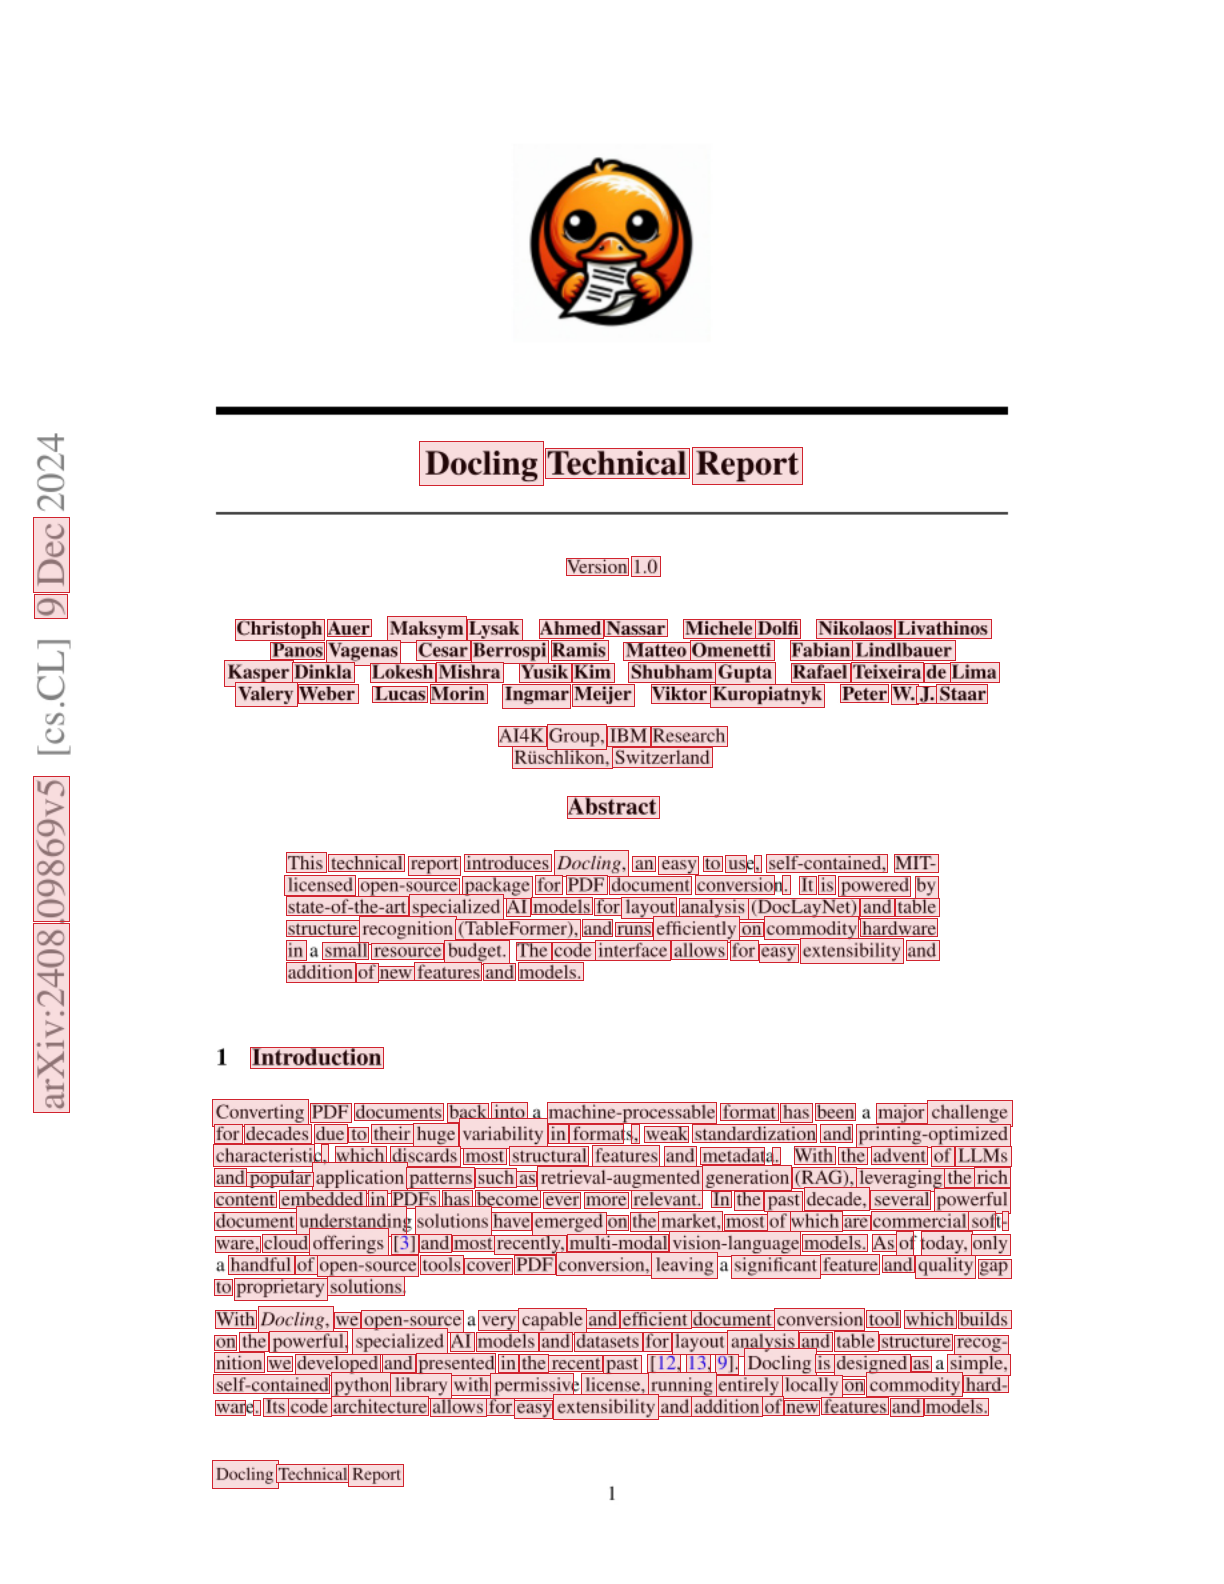

In [7]:
display(draw_word_boxes(scan_page))

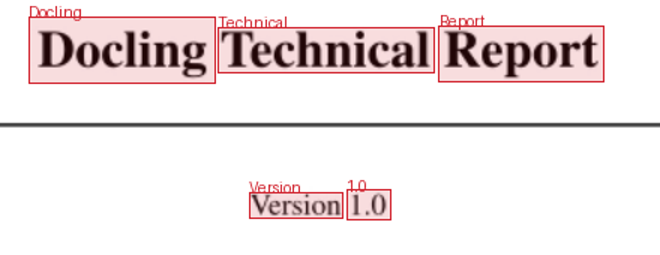

In [8]:
display(zoom(scan_page, (200, 215, 420, 300)))

## 3. Export

`ParsedDocument.as_dict()` gives a JSON-ready dump of every word box; the full
`DoclingDocument` (layout, reading order, tables, markdown) is on `.document`.

In [9]:
import json

print(json.dumps(parsed.as_dict()["pages"][0]["words"][:3], indent=2))
print(parsed.document.export_to_markdown()[:400])

[
  {
    "page_no": 1,
    "text": "Docling",
    "bbox": [
      212.59,
      225.36037399999998,
      269.02208120000006,
      240.83701860000008
    ],
    "confidence": 1.0,
    "from_ocr": false,
    "estimated": false
  },
  {
    "page_no": 1,
    "text": "Technical",
    "bbox": [
      273.32593120000007,
      225.36037399999998,
      343.4786862,
      240.83701860000008
    ],
    "confidence": 1.0,
    "from_ocr": false,
    "estimated": false
  },
  {
    "page_no": 1,
    "text": "Report",
    "bbox": [
      347.78253620000004,
      225.36037399999998,
      399.4115208,
      240.83701860000008
    ],
    "confidence": 1.0,
    "from_ocr": false,
    "estimated": false
  }
]
<!-- image -->

## Docling Technical Report

## Version 1.0

Christoph Auer Maksym Lysak Ahmed Nassar Michele Dolfi Nikolaos Livathinos Panos Vagenas Cesar Berrospi Ramis Matteo Omenetti Fabian Lindlbauer Kasper Dinkla Lokesh Mishra Yusik Kim Shubham Gupta Rafael Teixeira de Lima Valery Weber